In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b5, EfficientNet_B5_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
dataset_path = "/kaggle/input/datasets/mariaherrerot/aptos2019"

print(os.listdir(dataset_path))  

train_df = pd.read_csv(os.path.join(dataset_path, "train_1.csv"))
val_df = pd.read_csv(os.path.join(dataset_path, "valid.csv"))

train_img_path = os.path.join(dataset_path, "train_images", "train_images")
val_img_path = os.path.join(dataset_path, "val_images", "val_images")

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))

['val_images', 'train_images', 'valid.csv', 'test.csv', 'train_1.csv', 'test_images']
Train samples: 2930
Validation samples: 366


In [3]:
train_df["diagnosis"] = train_df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)
val_df["diagnosis"] = val_df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)

print(train_df["diagnosis"].value_counts())
print(val_df["diagnosis"].value_counts())


diagnosis
1    1496
0    1434
Name: count, dtype: int64
diagnosis
1    194
0    172
Name: count, dtype: int64


In [4]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class APTOSBinaryDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id_code"]
        label = self.df.iloc[idx]["diagnosis"]

        img_path = os.path.join(self.img_dir, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


In [5]:
import torchvision.transforms as transforms
from torchvision.models import EfficientNet_B5_Weights

weights = EfficientNet_B5_Weights.DEFAULT

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((456, 456)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize((456, 456)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

In [6]:
from torch.utils.data import DataLoader

train_dataset = APTOSBinaryDataset(train_df, train_img_path, train_transform)
val_dataset = APTOSBinaryDataset(val_df, val_img_path, val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)


In [7]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = efficientnet_b5(weights=weights)

model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier[1].in_features, 1)
)

model = model.to(device)

print("EfficientNet-B5 Pretrained Loaded")


Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 229MB/s] 


EfficientNet-B5 Pretrained Loaded


In [8]:
for param in model.features.parameters():
    param.requires_grad = False


In [9]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


In [10]:
from sklearn.metrics import accuracy_score

epochs = 8

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):

    model.train()
    running_loss = 0
    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(preds.cpu().detach().numpy())
        train_labels.extend(labels.cpu().detach().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    model.eval()
    val_running_loss = 0
    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step()

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")



Epoch 1
Train Loss: 0.5343 | Train Acc: 0.7932
Val Loss: 0.3648 | Val Acc: 0.9044

Epoch 2
Train Loss: 0.4221 | Train Acc: 0.8270
Val Loss: 0.2907 | Val Acc: 0.9235

Epoch 3
Train Loss: 0.3795 | Train Acc: 0.8457
Val Loss: 0.2522 | Val Acc: 0.9426

Epoch 4
Train Loss: 0.3490 | Train Acc: 0.8611
Val Loss: 0.2311 | Val Acc: 0.9508

Epoch 5
Train Loss: 0.3576 | Train Acc: 0.8573
Val Loss: 0.2188 | Val Acc: 0.9508

Epoch 6
Train Loss: 0.3738 | Train Acc: 0.8369
Val Loss: 0.2147 | Val Acc: 0.9481

Epoch 7
Train Loss: 0.3502 | Train Acc: 0.8539
Val Loss: 0.2133 | Val Acc: 0.9508

Epoch 8
Train Loss: 0.3507 | Train Acc: 0.8577
Val Loss: 0.2107 | Val Acc: 0.9536


In [11]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)



In [12]:
epochs_phase2 = 5

for epoch in range(epochs_phase2):

    model.train()
    running_loss = 0
    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(preds.cpu().detach().numpy())
        train_labels.extend(labels.cpu().detach().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    # Validation
    model.eval()
    val_running_loss = 0
    val_preds = []
    val_labels = []
    val_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    scheduler.step()

    print(f"\nFine-tune Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")



Fine-tune Epoch 1
Train Loss: 0.2880 | Train Acc: 0.8846
Val Loss: 0.1012 | Val Acc: 0.9809

Fine-tune Epoch 2
Train Loss: 0.2527 | Train Acc: 0.9051
Val Loss: 0.1020 | Val Acc: 0.9699

Fine-tune Epoch 3
Train Loss: 0.2356 | Train Acc: 0.9058
Val Loss: 0.0821 | Val Acc: 0.9809

Fine-tune Epoch 4
Train Loss: 0.1976 | Train Acc: 0.9171
Val Loss: 0.0702 | Val Acc: 0.9809

Fine-tune Epoch 5
Train Loss: 0.1932 | Train Acc: 0.9256
Val Loss: 0.0674 | Val Acc: 0.9809


In [13]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=4)

epochs = 4

for epoch in range(epochs):

    model.train()
    running_loss = 0
    train_preds = []
    train_labels = []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_preds.extend(preds.cpu().detach().numpy())
        train_labels.extend(labels.cpu().detach().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_running_loss = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs1 = model(images).squeeze()
            outputs2 = model(torch.flip(images, dims=[3])).squeeze()
            outputs = (outputs1 + outputs2) / 2

            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)

    scheduler.step()

    print(f"\nFinal Tune Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")



Final Tune Epoch 1
Train Loss: 0.2002 | Train Acc: 0.9273
Val Loss: 0.0534 | Val Acc: 0.9863

Final Tune Epoch 2
Train Loss: 0.2058 | Train Acc: 0.9334
Val Loss: 0.0484 | Val Acc: 0.9891

Final Tune Epoch 3
Train Loss: 0.1798 | Train Acc: 0.9413
Val Loss: 0.0473 | Val Acc: 0.9918

Final Tune Epoch 4
Train Loss: 0.1282 | Train Acc: 0.9526
Val Loss: 0.0503 | Val Acc: 0.9918


Validation AUC: 0.9977823064013426


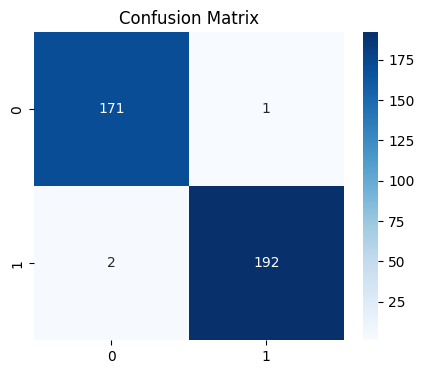

In [14]:
from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(val_labels, val_preds)
auc = roc_auc_score(val_labels, val_probs)

print("Validation AUC:", auc)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


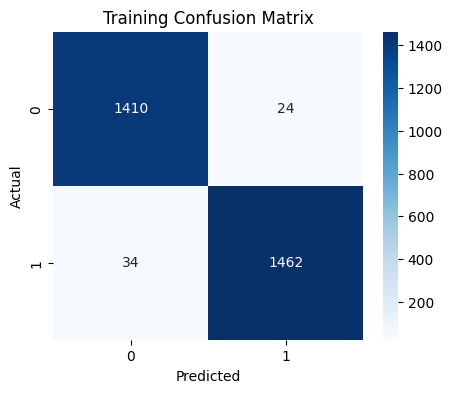

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()

train_preds = []
train_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        preds = (torch.sigmoid(outputs) > 0.5).float()

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.numpy())

cm_train = confusion_matrix(train_labels, train_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues")
plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


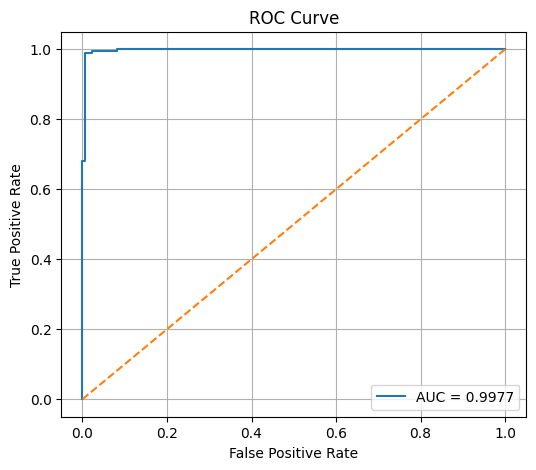

Validation AUC: 0.9976624310716854


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)

        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

fpr, tpr, thresholds = roc_curve(val_labels, val_probs)
auc_score = roc_auc_score(val_labels, val_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

print("Validation AUC:", auc_score)


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

def evaluate_model(loader, model):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).squeeze()
            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(all_labels, all_probs)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall (Sensitivity)": recall,
        "Specificity": specificity,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

train_metrics = evaluate_model(train_loader, model)
val_metrics = evaluate_model(val_loader, model)

results_table = pd.DataFrame([train_metrics, val_metrics],
                             index=["Training", "Validation"])

print("\n---- FINAL PERFORMANCE TABLE ----\n")
print(results_table.round(4))



---- FINAL PERFORMANCE TABLE ----

            Accuracy  Precision  Recall (Sensitivity)  Specificity  F1 Score  \
Training      0.9816     0.9832                0.9806       0.9826    0.9819   
Validation    0.9891     0.9948                0.9845       0.9942    0.9896   

            ROC-AUC  
Training     0.9974  
Validation   0.9977  


In [18]:
if train_accs[-1] - val_accs[-1] > 0.05:
    print("Model may be overfitting.")
else:
    print("No significant overfitting detected.")


No significant overfitting detected.


In [34]:
torch.manual_seed(42)
torch.manual_seed(7)
torch.manual_seed(123)


===== CONFUSION MATRIX =====
[[171   1]
 [  3 191]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99       172
         1.0       0.99      0.98      0.99       194

    accuracy                           0.99       366
   macro avg       0.99      0.99      0.99       366
weighted avg       0.99      0.99      0.99       366


===== ADDITIONAL METRICS =====
MCC: 0.9781
Cohen’s Kappa: 0.9781
Balanced Accuracy: 0.9894


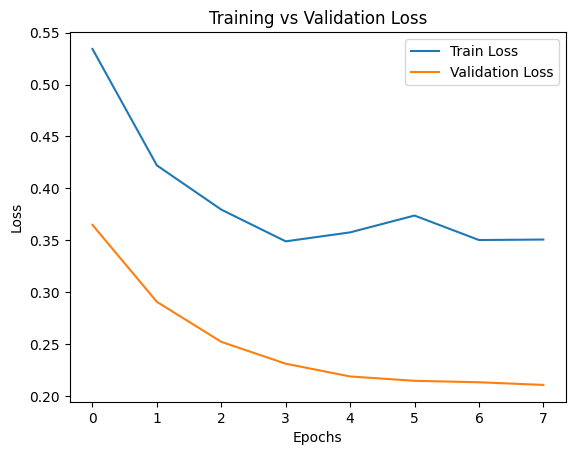


===== OVERFITTING CHECK =====
Accuracy values not provided → skipping accuracy gap check.
Validation loss stable → no strong overfitting.


In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    # Metrics
    mcc = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    print("\n===== CONFUSION MATRIX =====")
    print(confusion_matrix(all_labels, all_preds))

    print("\n===== CLASSIFICATION REPORT =====")
    print(classification_report(all_labels, all_preds))

    print("\n===== ADDITIONAL METRICS =====")
    print(f"MCC: {mcc:.4f}")
    print(f"Cohen’s Kappa: {kappa:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")

    return mcc, kappa, bal_acc


def plot_learning_curves(train_losses, val_losses):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend(["Train Loss", "Validation Loss"])
    plt.show()


def check_overfitting(train_losses, val_losses, train_accuracies=None, val_accuracies=None):

    print("\n===== OVERFITTING CHECK =====")

    if train_accuracies is not None and val_accuracies is not None:
        train_acc = train_accuracies[-1]
        val_acc = val_accuracies[-1]
        gap = train_acc - val_acc

        print(f"Final Train Accuracy: {train_acc:.4f}")
        print(f"Final Val Accuracy: {val_acc:.4f}")
        print(f"Generalization Gap: {gap:.4f}")

        if abs(gap) < 0.02:
            print("Model is well-generalized.")
        elif abs(gap) < 0.05:
            print("Slight overfitting.")
        else:
            print("Possible overfitting detected.")

    else:
        print("Accuracy values not provided → skipping accuracy gap check.")

    if val_losses[-1] > min(val_losses):
        print("Validation loss increased after minimum → possible overfitting.")
    else:
        print("Validation loss stable → no strong overfitting.")

mcc, kappa, bal_acc = evaluate_model(model, val_loader, device)

plot_learning_curves(train_losses, val_losses)

check_overfitting(train_losses, val_losses)

In [38]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

def plot_pr_curve(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
    plt.show()

    print(f"PR-AUC: {pr_auc:.4f}")


In [39]:
from sklearn.metrics import recall_score, precision_score

def threshold_analysis(model, dataloader, device):
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    for t in thresholds:
        preds = (all_probs > t).astype(int)
        recall = recall_score(all_labels, preds)
        precision = precision_score(all_labels, preds)
        print(f"Threshold {t} → Recall: {recall:.4f}, Precision: {precision:.4f}")


In [40]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

def bootstrap_ci(labels, preds, n_iterations=1000):
    scores = []
    for _ in range(n_iterations):
        idx = np.random.choice(len(labels), len(labels), replace=True)
        score = accuracy_score(labels[idx], preds[idx])
        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    print(f"95% Confidence Interval: {lower:.4f} – {upper:.4f}")


In [41]:
from sklearn.calibration import calibration_curve

def plot_calibration(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    prob_true, prob_pred = calibration_curve(all_labels, all_probs, n_bins=10)

    plt.figure()
    plt.plot(prob_pred, prob_true)
    plt.plot([0,1],[0,1])
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.title("Calibration Curve")
    plt.show()


In [46]:
def add_gaussian_noise(images, std=0.05):
    noise = torch.randn_like(images) * std
    return images + noise



===== PRECISION-RECALL CURVE =====


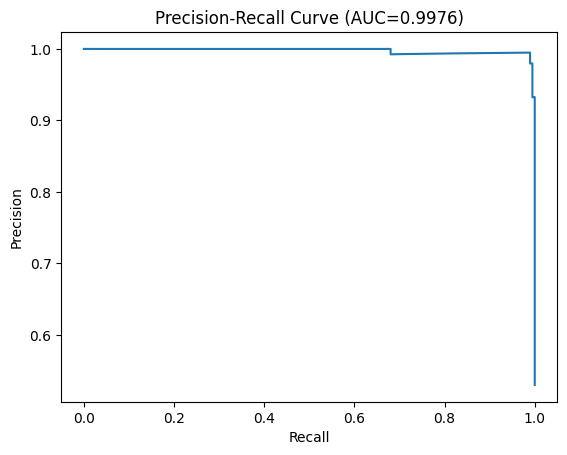

PR-AUC: 0.9976

===== THRESHOLD ANALYSIS =====
Threshold 0.3 → Recall: 0.9897, Precision: 0.9948
Threshold 0.4 → Recall: 0.9897, Precision: 0.9948
Threshold 0.5 → Recall: 0.9845, Precision: 0.9948
Threshold 0.6 → Recall: 0.9794, Precision: 0.9948
Threshold 0.7 → Recall: 0.9794, Precision: 0.9948

===== BOOTSTRAP CONFIDENCE INTERVAL =====
95% Confidence Interval: 0.9754 – 0.9973

===== CALIBRATION CURVE =====


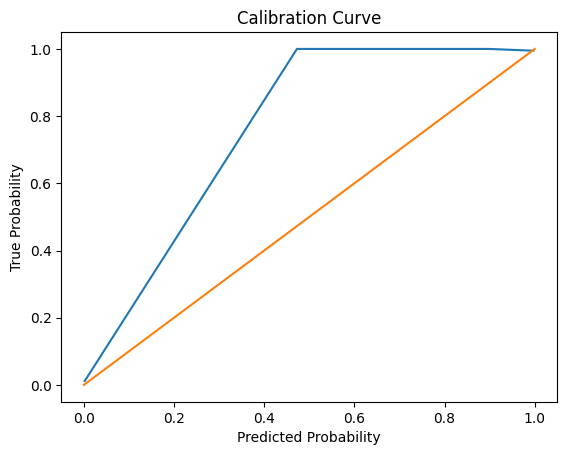

In [48]:
print("\n===== PRECISION-RECALL CURVE =====")
plot_pr_curve(model, val_loader, device)


print("\n===== THRESHOLD ANALYSIS =====")
threshold_analysis(model, val_loader, device)


model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs).flatten()
all_labels = np.array(all_labels).flatten()
all_preds = (all_probs > 0.5).astype(int)

print("\n===== BOOTSTRAP CONFIDENCE INTERVAL =====")
bootstrap_ci(all_labels, all_preds)


print("\n===== CALIBRATION CURVE =====")
plot_calibration(model, val_loader, device)


In [29]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, matthews_corrcoef
from PIL import Image
import timm
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [30]:
BASE_PATH = "/kaggle/input/datasets/andrewmvd/retinal-disease-classification"

TRAIN_IMG_PATH = os.path.join(BASE_PATH, "Training_Set/Training_Set/Training")
TRAIN_CSV = os.path.join(BASE_PATH, "Training_Set/Training_Set/RFMiD_Training_Labels.csv")

VAL_IMG_PATH = os.path.join(BASE_PATH, "Evaluation_Set/Evaluation_Set/Validation")
VAL_CSV = os.path.join(BASE_PATH, "Evaluation_Set/Evaluation_Set/RFMiD_Validation_Labels.csv")

In [31]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# Binary target (Disease_Risk column)
train_df["binary"] = train_df["Disease_Risk"]
val_df["binary"] = val_df["Disease_Risk"]

train_df["path"] = train_df["ID"].astype(str) + ".png"
val_df["path"] = val_df["ID"].astype(str) + ".png"

print(train_df["binary"].value_counts())

binary
1    1519
0     401
Name: count, dtype: int64


In [34]:
class RFMiDDataset(Dataset):
    def __init__(self, dataframe, img_path, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_path = img_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "binary"]

        image = Image.open(os.path.join(self.img_path, img_name)).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [35]:
transform_train = transforms.Compose([
    transforms.Resize((456, 456)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((456,456)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [37]:
train_loader = DataLoader(
    RFMiDDataset(train_df, TRAIN_IMG_PATH, transform_train),
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    RFMiDDataset(val_df, VAL_IMG_PATH, transform_val),
    batch_size=4,
    shuffle=False
)

In [38]:
model = timm.create_model("efficientnet_b5", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 1)
model = model.to(DEVICE)

In [40]:
# Handle imbalance
pos_count = train_df["binary"].sum()
neg_count = len(train_df) - pos_count
pos_weight = torch.tensor([neg_count / pos_count]).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

In [41]:
best_acc = 0

for epoch in range(15):
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    # Validation
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            predictions = (probs > 0.5).int()

            preds.extend(predictions.cpu().numpy())
            labels_all.extend(labels.numpy())

    acc = accuracy_score(labels_all, preds)
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_model_b5.pth")

print("Best Validation Accuracy:", best_acc)

100%|██████████| 480/480 [07:05<00:00,  1.13it/s]


Epoch 1 | Loss: 0.2273 | Val Acc: 0.8266


100%|██████████| 480/480 [07:04<00:00,  1.13it/s]


Epoch 2 | Loss: 0.1865 | Val Acc: 0.8672


100%|██████████| 480/480 [07:02<00:00,  1.14it/s]


...

Epoch 13 | Loss: 0.0430 | Val Acc: 0.8672


100%|██████████| 480/480 [07:04<00:00,  1.13it/s]


Epoch 14 | Loss: 0.0315 | Val Acc: 0.8844


100%|██████████| 480/480 [07:01<00:00,  1.14it/s]


Epoch 15 | Loss: 0.0295 | Val Acc: 0.8812
Best Validation Accuracy: 0.884375


In [42]:
model.load_state_dict(torch.load("best_model_b5.pth"))

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6)

for epoch in range(5):
    model.train()
    for images, labels in tqdm(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"Fine-tune Epoch {epoch+1} done")

100%|██████████| 480/480 [05:20<00:00,  1.50it/s]


Fine-tune Epoch 1 done


100%|██████████| 480/480 [05:20<00:00,  1.50it/s]


Fine-tune Epoch 2 done


100%|██████████| 480/480 [05:20<00:00,  1.50it/s]


Fine-tune Epoch 3 done


100%|██████████| 480/480 [05:21<00:00,  1.50it/s]


Fine-tune Epoch 4 done


100%|██████████| 480/480 [05:21<00:00,  1.49it/s]

Fine-tune Epoch 5 done


In [43]:
model.eval()
preds, labels_all = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        predictions = (probs > 0.5).int()

        preds.extend(predictions.cpu().numpy())
        labels_all.extend(labels.numpy())

acc = accuracy_score(labels_all, preds)
mcc = matthews_corrcoef(labels_all, preds)

print("Final Accuracy:", acc)
print("Final MCC:", mcc)

Final Accuracy: 0.878125
Final MCC: 0.6490583743768443
